In [ ]:
# Colab Setup: Run this cell first!
%pip install -q openai pydantic

from google.colab import userdata, drive
import os

os.environ["OPENAI_API_KEY"] = userdata.get("OPENAI_API_KEY")

# Mount Google Drive for saving output files
drive.mount("/content/drive")

# 05 - Putting It All Together: Player Cards

This is the payoff. We're going to combine everything you've learned:

- **Functions** — Reusable code
- **Loops** — Process multiple texts (SCALE)
- **API calls** — Talk to AI from code (CHAINING)
- **Structured output** — Get organized data (CONTROL)

**Goal:** Loop through 3 passages, extract structured data, generate card art with DALL-E, and save everything for use in a Next.js app.

---

## Setup

In [1]:
import os
import json
import requests
from pathlib import Path
from pydantic import BaseModel
from IPython.display import Image, display

if not os.environ.get("OPENAI_API_KEY"):
    raise EnvironmentError("OPENAI_API_KEY not found! Add it to Colab Secrets.")

from openai import OpenAI
client = OpenAI()

# Output paths for the Next.js app
IMAGES_DIR = Path("/content/drive/MyDrive/complit-126x/cards")
DATA_DIR = Path("/content/drive/MyDrive/complit-126x/data")

# Create directories if they don't exist
IMAGES_DIR.mkdir(parents=True, exist_ok=True)
DATA_DIR.mkdir(parents=True, exist_ok=True)

print("✓ Ready")
print(f"✓ Images will be saved to: {IMAGES_DIR}")
print(f"✓ Data will be saved to: {DATA_DIR}")

✓ Ready
✓ Images will be saved to: /workspaces/complit-126x/apps/interface/public/cards
✓ Data will be saved to: /workspaces/complit-126x/apps/interface/data


## Our Three Passages

Three creation narratives from different traditions:

In [3]:
passages = [
    {
        "id": "genesis",
        "name": "Genesis",
        "text": """In the beginning God created the heaven and the earth. And the earth was without form, and void; and darkness was upon the face of the deep. And the Spirit of God moved upon the face of the waters. And God said, Let there be light: and there was light. And God saw the light, that it was good: and God divided the light from the darkness."""
    },
    {
        "id": "theogony",
        "name": "Hesiod's Theogony",
        "text": """First of all, the Void came into being, next broad-bosomed Earth, the solid and eternal home of all, and Eros, the most beautiful of the immortal gods, who in every man and every god softens the sinews and overpowers the prudent purpose of the mind. Out of Void came Darkness and black Night, and out of Night came Light and Day, her children conceived after union in love with Darkness."""
    },
    {
        "id": "metamorphoses",
        "name": "Ovid's Metamorphoses",
        "text": """Before the sea and lands began to be, before the sky had mantled everything, Nature displayed a single face, which they called Chaos: a raw and undivided mass, nothing but weight, lifeless, whose components were heaped together, where seeds of things had been rudely lumped, of things in strife, things jostled by things."""
    }
]

---

## Step 1: Define the Card Schema

In [4]:
class PlayerCard(BaseModel):
    title: str
    source: str
    era: str
    themes: list[str]
    key_images: list[str]
    mood: str
    flavor_quote: str
    power_rating: int  # 1-10 based on cosmic/mythic significance
    art_prompt: str    # A prompt to generate card art with DALL-E

---

## Step 2: Create the Extraction and Image Generation Functions

In [5]:
def extract_card(name: str, text: str) -> PlayerCard:
    """Extract a PlayerCard from a passage using structured output."""
    response = client.beta.chat.completions.parse(
        model="gpt-4o-mini",
        messages=[
            {
                "role": "user",
                "content": f"""You are a literary analyst creating player cards for mythological and literary texts.
Extract the key information and rate the cosmic/mythic significance from 1-10.
For the art_prompt, create a vivid visual description suitable for generating card art.
Style: epic fantasy card game art, dramatic lighting, mythological themes.

Create a player card for this passage from {name}:

{text}"""
            }
        ],
        response_format=PlayerCard
    )
    return response.choices[0].message.parsed


def generate_card_art(art_prompt: str, card_id: str) -> str:
    """Generate art using DALL-E 3, save to Drive folder, return the path."""
    # Generate image
    response = client.images.generate(
        model="dall-e-3",
        prompt=art_prompt,
        size="1024x1024",
        quality="standard",
        n=1
    )
    image_url = response.data[0].url
    
    # Download and save
    filename = f"{card_id}.png"
    filepath = IMAGES_DIR / filename
    img_data = requests.get(image_url).content
    filepath.write_bytes(img_data)
    
    # Return the path
    return str(filepath)


def process_passage(passage: dict) -> dict:
    """Extract card data and generate art for a passage. Returns complete card dict."""
    card_id = passage["id"]
    
    # Extract structured data
    print(f"  Extracting data...")
    card = extract_card(passage["name"], passage["text"])
    
    # Generate art
    print(f"  Generating art...")
    image_path = generate_card_art(card.art_prompt, card_id)
    
    # Combine into final card data
    card_data = card.model_dump()
    card_data["id"] = card_id
    card_data["image_path"] = image_path
    card_data["original_text"] = passage["text"]
    
    return card_data

---

## Step 3: Test on One Passage

In [6]:
# Test on Genesis
print("Processing Genesis...")
test_card = process_passage(passages[0])
print(f"  ✓ Done!")
print()
print("Card data:")
print(json.dumps(test_card, indent=2))

Processing Genesis...
  Extracting data...
  Generating art...
  ✓ Done!

Card data:
{
  "title": "Creation of Light",
  "source": "Genesis 1:1-4",
  "era": "Ancient",
  "themes": [
    "Creation",
    "Duality",
    "Divine Intervention",
    "Light vs Darkness"
  ],
  "key_images": [
    "A vast void with swirling dark waters",
    "A radiant burst of light breaking through darkness",
    "The silhouette of God transcending the cosmos",
    "Divided realms of light and dark"
  ],
  "mood": "Transcendental Awe",
  "flavor_quote": "And God said, Let there be light: and there was light.",
  "power_rating": 10,
  "art_prompt": "A cosmic scene depicting the moment of creation: a dark void filled with turbulent waters, illuminated by a radiant burst of divine light emerging from the center. God, an ethereal figure with majestic wings and glowing aura, stands amidst the light, casting shadows away as beams of golden sunlight pierce through the darkness. The contrast between the vibrant ligh

Title: Creation of Light
Image saved to: /cards/genesis.png


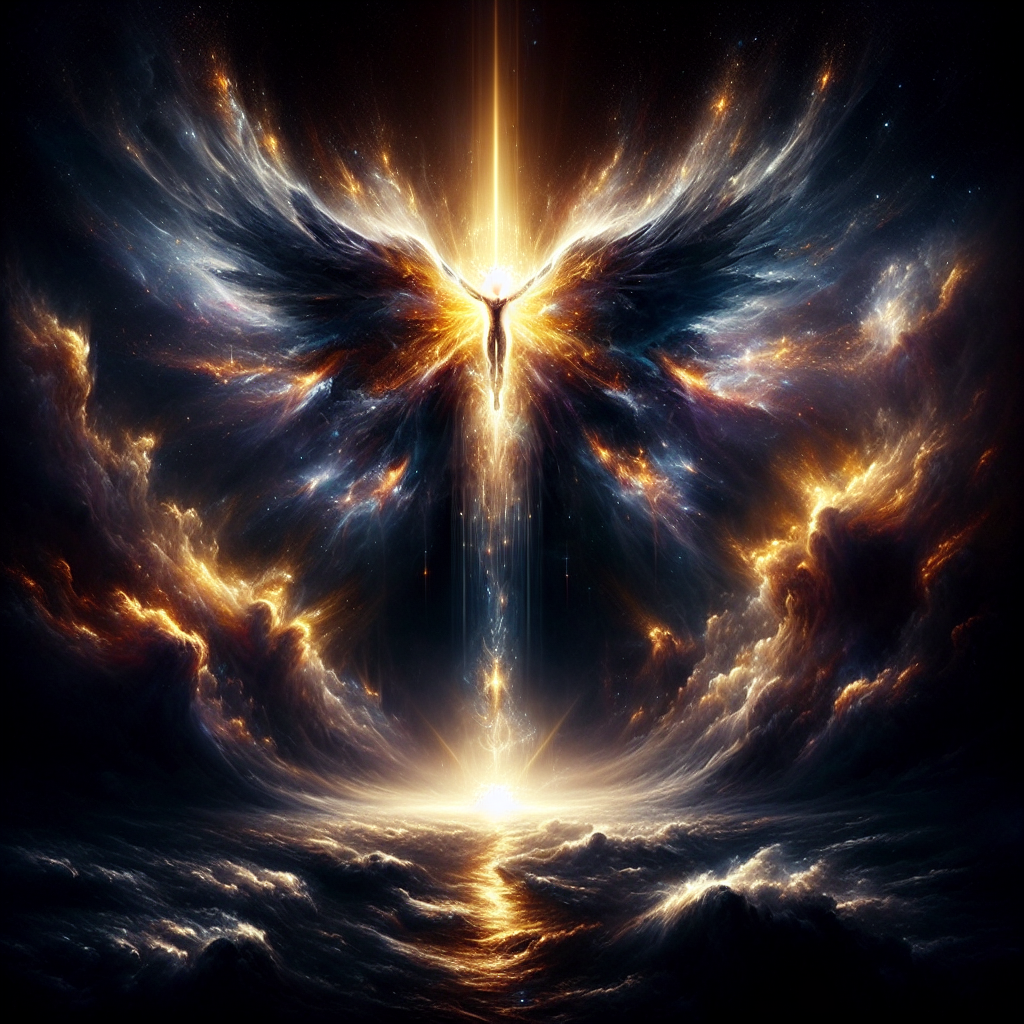

In [7]:
# Display the generated image
print(f"Title: {test_card['title']}")
print(f"Image saved to: {test_card['image_path']}")
display(Image(filename=str(IMAGES_DIR / f"{passages[0]['id']}.png"), width=400))

---

## Step 4: Process All Passages

In [8]:
# Process all passages (including the one we already did)
cards = []

for passage in passages:
    print(f"Processing {passage['name']}...")
    
    # Check if we already processed this one (from test)
    if passage['id'] == 'genesis' and test_card:
        card_data = test_card
        print("  (using cached result)")
    else:
        card_data = process_passage(passage)
    
    cards.append(card_data)
    print(f"  ✓ Done!")

print(f"\n✓ Processed {len(cards)} cards!")

Processing Genesis...
  (using cached result)
  ✓ Done!
Processing Hesiod's Theogony...
  Extracting data...
  Generating art...
  ✓ Done!
Processing Ovid's Metamorphoses...
  Extracting data...
  Generating art...
  ✓ Done!

✓ Processed 3 cards!


---

## Step 5: Display All Cards

In [9]:
def display_card(card: dict):
    """Display a card with its image."""
    print("=" * 60)
    print(f"  {card['title'].upper()}")
    print("=" * 60)
    
    # Show image
    img_file = IMAGES_DIR / f"{card['id']}.png"
    if img_file.exists():
        display(Image(filename=str(img_file), width=350))
    
    print(f"Source: {card['source']}")
    print(f"Era: {card['era']}")
    print(f"Mood: {card['mood']}")
    print(f"Power Rating: {'⭐' * card['power_rating']} ({card['power_rating']}/10)")
    print()
    print("Themes:", ", ".join(card['themes']))
    print()
    print(f'"{card["flavor_quote"]}"')
    print("=" * 60)
    print()

  CREATION OF LIGHT


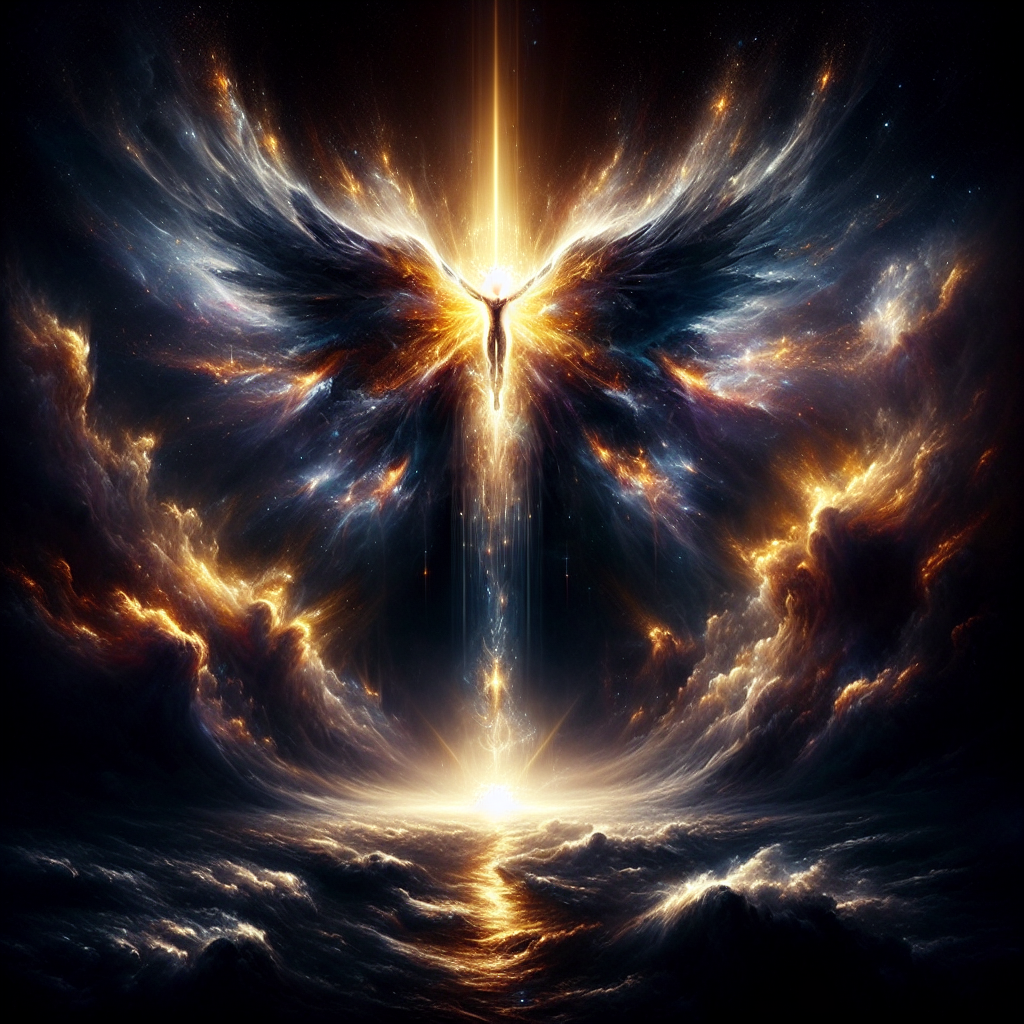

Source: Genesis 1:1-4
Era: Ancient
Mood: Transcendental Awe
Power Rating: ⭐⭐⭐⭐⭐⭐⭐⭐⭐⭐ (10/10)

Themes: Creation, Duality, Divine Intervention, Light vs Darkness

"And God said, Let there be light: and there was light."

  CREATION OF THE COSMOS


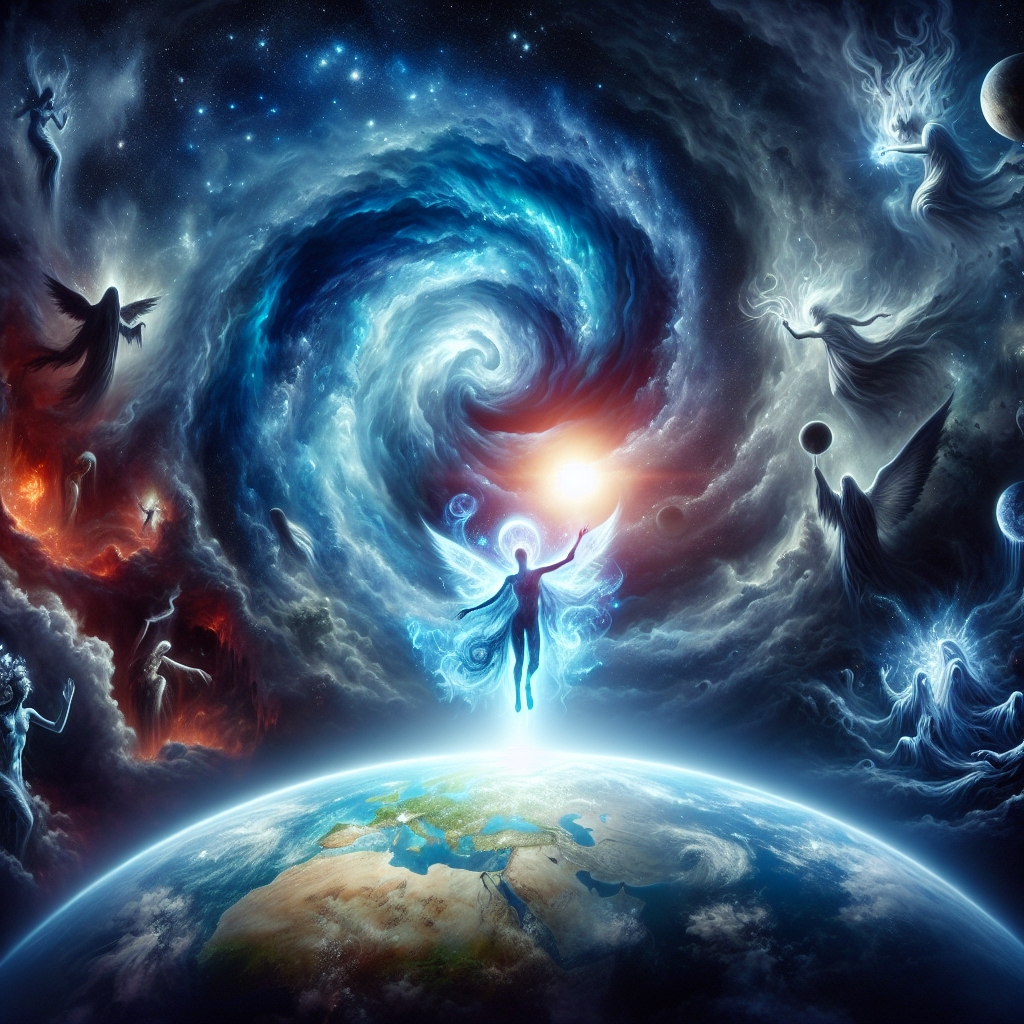

Source: Hesiod's Theogony
Era: Ancient Greece
Mood: Epic and Mystical
Power Rating: ⭐⭐⭐⭐⭐⭐⭐⭐⭐⭐ (10/10)

Themes: Cosmogony, Dichotomy of Light and Darkness, Power of Love, Eternal Struggle

"From the Void sprang forth the eternal; out of Darkness, Light embraced the world."

  CHAOS: THE PREGNANT VOID


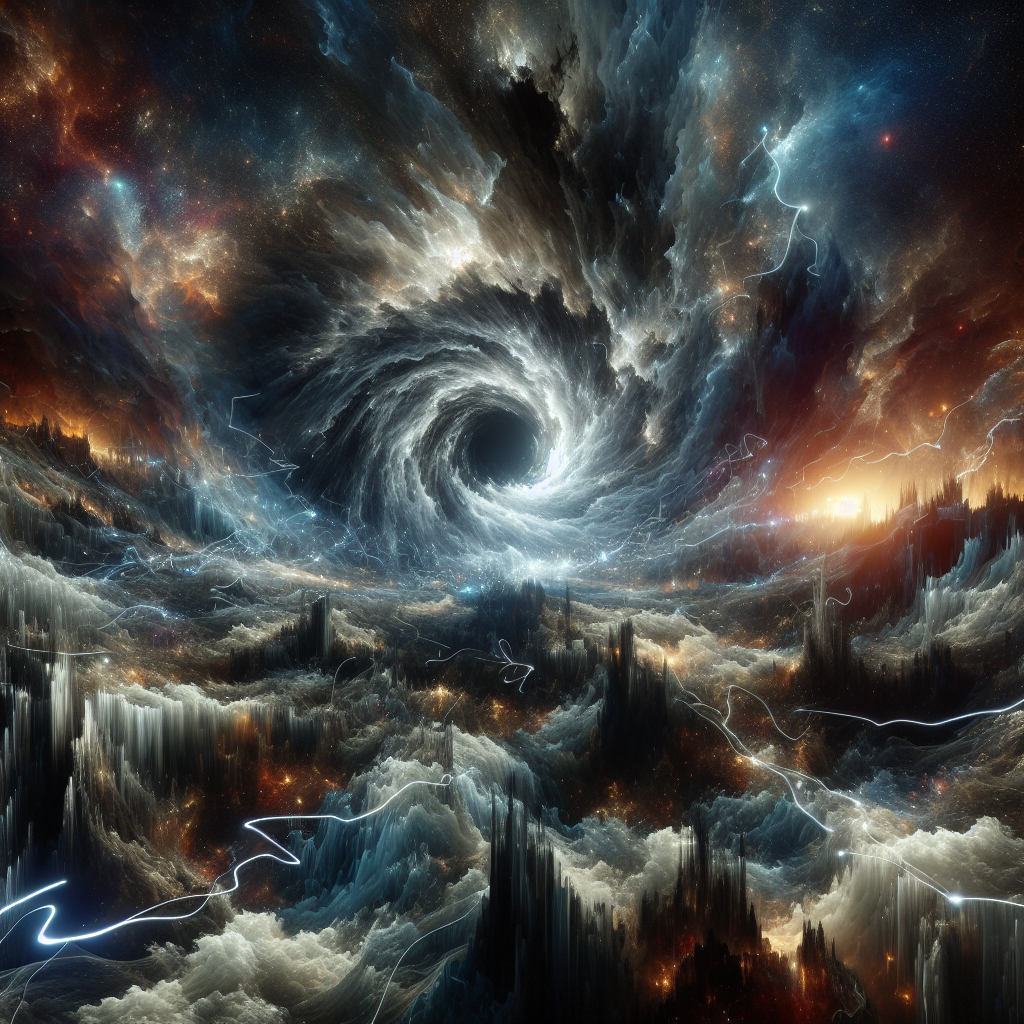

Source: Ovid's Metamorphoses
Era: Roman Mythology
Mood: Eerie and Momentous
Power Rating: ⭐⭐⭐⭐⭐⭐⭐⭐⭐ (9/10)

Themes: Creation, Cosmic Order, Duality, Transformation

"In the beginning, all was Chaos—a tumultuous womb of potentiality, waiting to be born."



In [10]:
# Display all cards
for card in cards:
    display_card(card)

---

## Step 6: Save Data for Next.js App

We'll save the card data as JSON so it can be used by the Next.js interface app.

In [11]:
# Save cards data to JSON
output_file = DATA_DIR / "cards.json"

with open(output_file, "w") as f:
    json.dump(cards, f, indent=2)

print(f"✓ Saved card data to: {output_file}")
print()
print("Preview:")
print(json.dumps(cards[0], indent=2)[:500] + "...")

✓ Saved card data to: /workspaces/complit-126x/apps/interface/data/cards.json

Preview:
{
  "title": "Creation of Light",
  "source": "Genesis 1:1-4",
  "era": "Ancient",
  "themes": [
    "Creation",
    "Duality",
    "Divine Intervention",
    "Light vs Darkness"
  ],
  "key_images": [
    "A vast void with swirling dark waters",
    "A radiant burst of light breaking through darkness",
    "The silhouette of God transcending the cosmos",
    "Divided realms of light and dark"
  ],
  "mood": "Transcendental Awe",
  "flavor_quote": "And God said, Let there be light: and there was...


In [12]:
# Verify what we saved
print("Files created:")
print()
print(f"Images ({IMAGES_DIR}):")
for f in IMAGES_DIR.glob("*.png"):
    print(f"  {f.name}")
print()
print(f"Data ({DATA_DIR}):")
for f in DATA_DIR.glob("*.json"):
    print(f"  {f.name}")

Files created:

Images (/workspaces/complit-126x/apps/interface/public/cards):
  genesis.png
  theogony.png
  metamorphoses.png

Data (/workspaces/complit-126x/apps/interface/data):
  cards.json


---

## Step 7: Compare the Cards

Because we have structured data, we can compare across cards:

In [13]:
# Compare power ratings
print("Power Rankings:")
print("-" * 30)
sorted_cards = sorted(cards, key=lambda c: c['power_rating'], reverse=True)
for i, card in enumerate(sorted_cards, 1):
    print(f"{i}. {card['title']}: {card['power_rating']}/10")

Power Rankings:
------------------------------
1. Creation of Light: 10/10
2. Creation of the Cosmos: 10/10
3. Chaos: The Pregnant Void: 9/10


In [14]:
# Find common themes across all cards
from collections import Counter

all_themes = []
for card in cards:
    all_themes.extend([t.lower() for t in card['themes']])

theme_counts = Counter(all_themes)

print("Common Themes Across All Cards:")
print("-" * 30)
for theme, count in theme_counts.most_common(10):
    if count > 1:
        print(f"  {theme}: appears in {count} cards")

Common Themes Across All Cards:
------------------------------
  creation: appears in 2 cards
  duality: appears in 2 cards


---

## What You Built

You just:
1. Defined a **schema** for what you wanted
2. Created **functions** to extract data and generate art
3. **Looped** through 3 passages automatically
4. Got **structured data** with generated images
5. **Saved everything** for use in a Next.js app

Your files are now ready:
- **Images:** `MyDrive/complit-126x/cards/*.png`
- **Data:** `MyDrive/complit-126x/data/cards.json`

---

## The Three Powers of Code

| Power | What it means | You used it when... |
|-------|--------------|--------------------|
| **SCALE** | Process many things automatically | You looped through 3 passages |
| **CHAINING** | Connect steps into workflows | You extracted → generated → saved |
| **CONTROL** | Get structured data, not paragraphs | You defined a schema and got organized cards |

These three powers are why coding with AI beats vanilla ChatGPT for serious work.

---

## What's Next?

Your card data and images are now in the Next.js app folder. Next steps:

1. **Build the UI** — Vibecode a Next.js page that displays the cards
2. **Add more passages** — Run this notebook with more texts
3. **Customize the schema** — Add fields like author, genre, literary devices
4. **Create a gallery** — Build a searchable, filterable card collection

You now have the tools. Go build something.